# HS4002 Week 1 Demo

## Basics of Python

We're working within the **pandas** + **plotnine** framework.

We'll explore a toy dataset about *Love Is Blind* contestants to answer: **to what extent does age, gender, and race affect the likelihood of marriage in LIB?**

In [2]:
   !pip install pandas numpy plotnine

zsh:1: command not found: pip


In [3]:
!python3 -m pip install pandas numpy plotnine

  Using cached pandas-3.0.5-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.5.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached mizani-0.14.4-py3-none-any.whl.metadata (4.8 kB)
  Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached statsmodels-0.14.6-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.5 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6

In [4]:
import pandas as pd
import numpy as np
import plotnine as p9
import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset

In [5]:
file_location = "lib_toy.csv"
df = pd.read_csv(file_location)

# What does a dataset usually look like?

In [6]:
df.head()

,Name,Season,Partner,Age,Married,Race,Gender,Unnamed: 7
0,Lauren Speed,1,Cameron Hamilton,32,1,Black,1,LIB + Lauren Speed
1,Cameron Hamilton,1,Lauren Speed,28,1,White,0,LIB + Cameron Hamilton
2,Amber Pike,1,Matthew Barnett,27,1,White,1,LIB + Amber Pike
3,Matthew Barnett,1,Amber Pike,27,1,White,0,LIB + Matthew Barnett
4,Giannina Gibelli,1,Damian Powers,25,0,Hispanic,1,LIB + Giannina Gibelli


# Univariate Analysis

In [ ]:
df.describe()

In [ ]:
df['Race'].value_counts()

## How many seasons of LIB are in this dataset?

In [ ]:
df['Season'].value_counts()

## How many contestants got married?

In [ ]:
df['Married'].value_counts()

## Univariate Plots

Let's make a histogram of the age distribution using `plotnine` — the grammar is identical to ggplot2. Note that column names in `aes()` are quoted strings in Python.

In [ ]:
(
    p9.ggplot(df) +
    p9.geom_histogram(p9.aes(x='Age'), binwidth=0.5)
)

In [ ]:
fig_fn = "ntu4eva.png"

p = (
    p9.ggplot(df) +
    p9.geom_histogram(p9.aes(x="Age"), binwidth=0.5, fill="red") +
    p9.theme_light() +
    p9.xlim(18, 40) +
    p9.labs(y="Count", x="Age", title="Age Distribution of Love is Blind Contestants")
)
p.save(fig_fn, width=30, height=17, units="cm")
p

In [ ]:
fig_fn = "ntu4eva.png"

p = (
    p9.ggplot(df) +
    p9.geom_density(p9.aes(x="Age"), fill="steelblue") +
    p9.theme_light() +
    p9.xlim(18, 40) +
    p9.labs(y="Density", x="Age", title="Age of Love is Blind Contestants")
)
p.save(fig_fn, width=30, height=17, units="cm")
p

# Does Age Matter?

How does age relate to the likelihood of a contestant getting married?

In [ ]:
df.groupby('Married')['Age'].mean()

In [ ]:
fig_fn = "age_by_maritalstatus.png"

p = (
    p9.ggplot(df) +
    p9.geom_density(p9.aes(x="Age", fill="factor(Married)"), position="identity", alpha=0.5) +
    p9.theme_light() +
    p9.xlim(18, 40) +
    p9.labs(y="Density", x="Age",
         title="Age Distribution of Love is Blind Contestants",
         fill="Married")
)
p.save(fig_fn, width=30, height=17, units="cm")
p

# Let's Throw Race Into the Mix

In [ ]:
df.groupby(['Married', 'Race'])['Age'].mean()

In [ ]:
fig_fn = "age_marital_race.png"

p = (
    p9.ggplot(df) +
    p9.geom_density(p9.aes(x="Age", fill="factor(Married)"), position="identity", alpha=0.5) +
    p9.facet_wrap("Race") +
    p9.theme_light() +
    p9.xlim(18, 40) +
    p9.labs(y="Density", x="Age",
         title="Age Distribution of Love is Blind Contestants",
         fill="Married")
)
p.save(fig_fn, width=30, height=17, units="cm")
p

# Trying Adding Gender!

In [7]:
df = df.assign(Gender=np.where(df['Gender'] == 1, 'Woman', 'Man'))

df.groupby(['Married', 'Gender'])['Age'].mean()

Married  Gender
0        Man       30.204545
         Woman     31.068182
1        Man       31.250000
         Woman     30.562500
Name: Age, dtype: float64

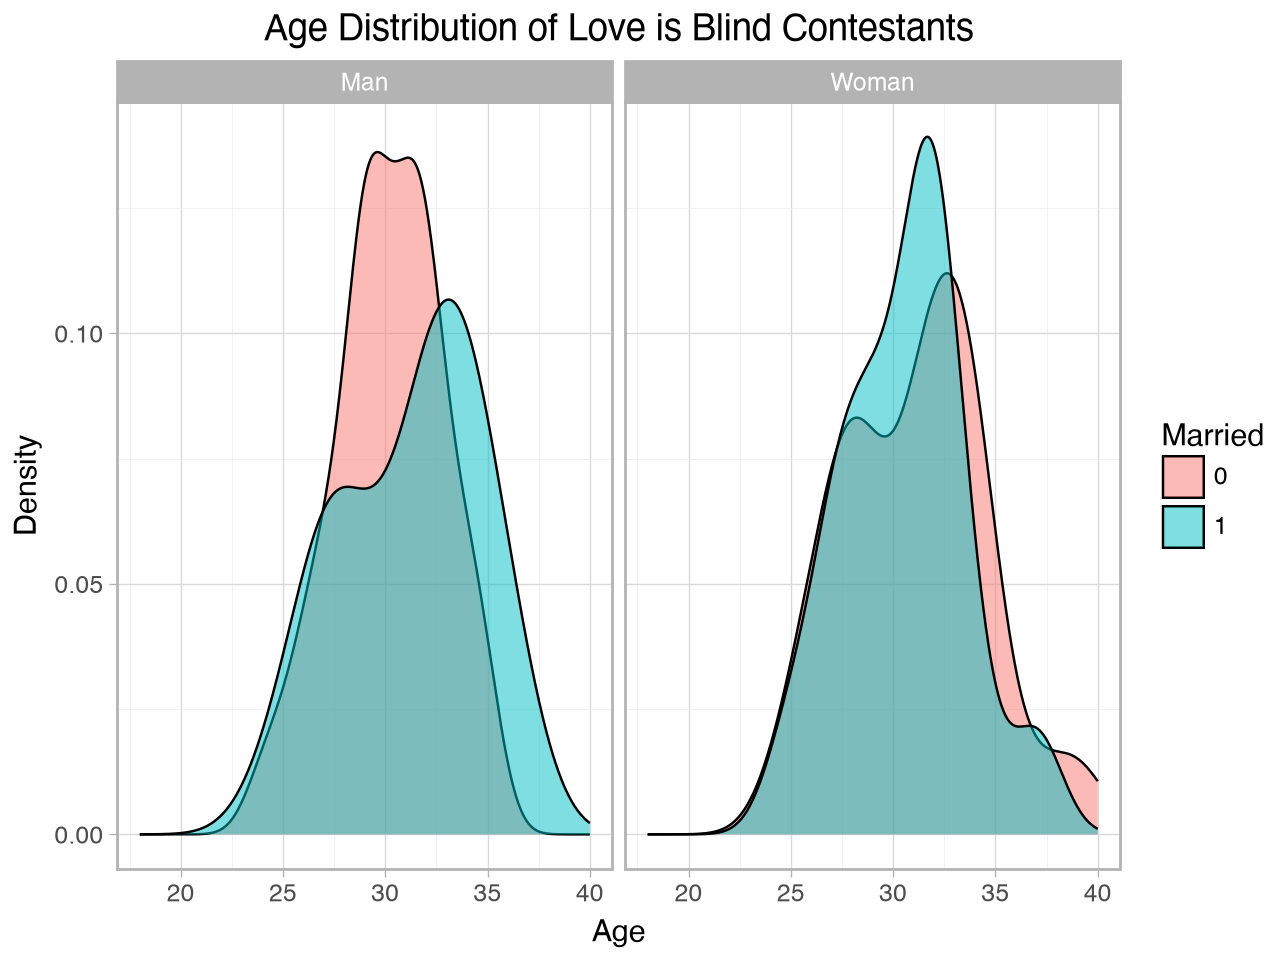

In [8]:
fig_fn = "age_marital_gender.png"

p = (
    p9.ggplot(df) +
    p9.geom_density(p9.aes(x="Age", fill="factor(Married)"), position="identity", alpha=0.5) +
    p9.facet_wrap("Gender") +
    p9.theme_light() +
    p9.xlim(18, 40) +
    p9.labs(y="Density", x="Age",
         title="Age Distribution of Love is Blind Contestants",
         fill="Married")
)
p.save(fig_fn, width=30, height=17, units="cm")
p